# M2A10 - Modelos Pré-Treinados

Na prática de hoje vamos utilizar modelos de aprendizado profundo pré-treinados, e para isso vamos utilizar [PyTorch](https://pytorch.org/).

Esse notebook está estruturado da seguinte forma.

- Introdução
- Modelos Pré-treinados
- Próximos passos
- Atividade Complementares

## Introdução

Instalação para os que ainda não possuem a biblioteca instalada.

In [1]:
%pip install torch torchvision


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip


Importar as bibliotecas e Ler Imagens do Disco

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
import torchvision

In [5]:
# TODO Atualize o path da imagem.
image = cv2.imread("/Users/julianapereirademagalhaes/Downloads/visaocomp/projetos_aulas/OneDrive_2_1-21-2026/VC_M2A10 - Modelos Pré-Treinados/dog.jpeg")


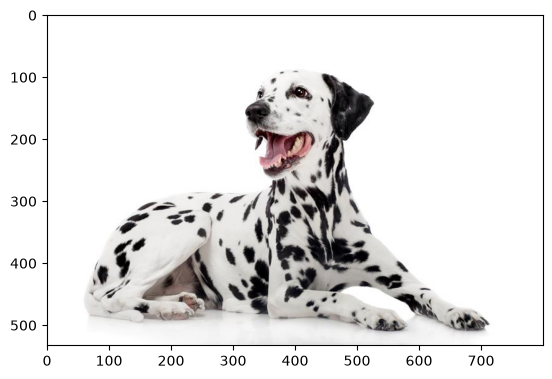

In [6]:
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

## Modelos Pré-Treinados

A primeira coisa para utilizar modelos pré-treinados é carregar seus pesos pré-treinados, utilizamos a biblioteca PyTorch para isso.

In [9]:
# Definindo os pesos a serem utilizados.
weights = torchvision.models.VGG16_Weights.DEFAULT

# Carregar os labels do dataset.
imagenet_labels = weights.meta["categories"] 

# Carregar o modelo.
vgg_16_model = torchvision.models.vgg16(weights)

# Criando o pipeline de transformações de pré-processamento dos dados.
preprocess = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize(256),
    torchvision.transforms.CenterCrop(224),
    torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# weights = torchvision.models.VGG16_Weights.DEFAULT

# imagenet_labels = weights.meta["categories"]

# vgg_16_model = torchvision.models.vgg16(weights=weights)

# preprocess = weights.transforms()

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/torchvision/models/_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(


In [10]:
# Vamos colocar o modelo em modo de avaliação.
vgg_16_model.eval()


# Pré processando a imagem.
image_tensor = preprocess(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
input_batch = image_tensor.unsqueeze(0) 


In [11]:
# Escolhendo o dispositivo a ser utilizado GPU se disponível.
if torch.cuda.is_available():
    input_batch = input_batch.to('cuda')
    vgg_16_model.to('cuda')

# Rodando a inferência.
with torch.no_grad():
    output = vgg_16_model(input_batch)

# Calculando as probabilidades das classes.
probabilities = torch.nn.functional.softmax(output[0], dim=0)

Classe predita para imagem: dalmatian


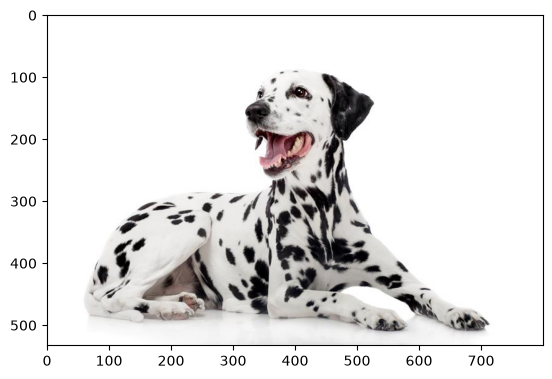

In [12]:
# Validando a classe prevista.
print(f"Classe predita para imagem: {imagenet_labels[torch.argmax(probabilities)]}")
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'EntleBucher'),
  Text(1, 0, 'boxer'),
  Text(2, 0, 'American Staffordshire terrier'),
  Text(3, 0, 'kuvasz'),
  Text(4, 0, 'bluetick'),
  Text(5, 0, 'muzzle'),
  Text(6, 0, 'German short-haired pointer'),
  Text(7, 0, 'English setter'),
  Text(8, 0, 'Great Dane'),
  Text(9, 0, 'dalmatian')])

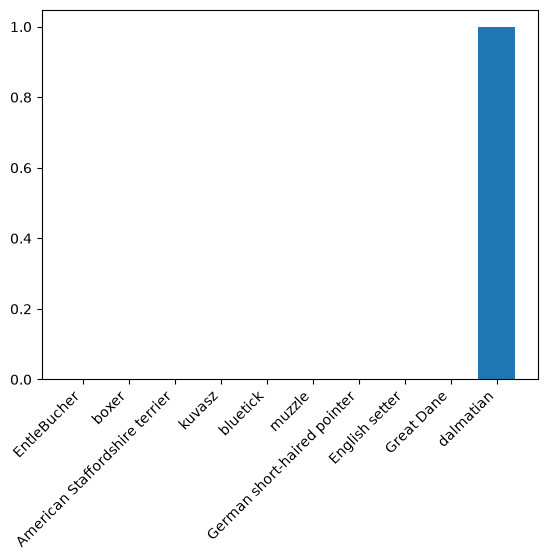

In [13]:
# Criar conjunto de labels e probabilidades, e ordenar.
set_labels_probs = list(zip(imagenet_labels, list(probabilities.cpu().numpy())))
set_labels_probs = sorted(set_labels_probs, key=lambda x: x[1])

# Pega as N classes mais prováveis.
num = 10
most_probable_classes = set_labels_probs[-num:]

# Criar as listas para o plot.
labels, probs = zip(*most_probable_classes)

# Observando as probabilidades.
plt.bar(labels, probs)
plt.xticks(rotation=45, ha='right') # Rotate labels by 45 degrees and align right


E assim terminamos a prática de hoje.

## Próximos Passos e Referências

Nas próximas práticas iremo avançar ainda mais no mundo de Visão Computacional.

Uma lista não exaustiva de referências segue:

- https://pytorch.org/
- https://docs.pytorch.org/vision/main/models.html
- https://opencv.org/
- https://learnopencv.com/blogs/
- https://pyimagesearch.com/

## Atividades Complementares (Opicional)

- [ ] Rode a inferência com outra imagem.
- [ ] Tente utilizar outro modelo pré-treinado da mesma forma que utilizamos o modelo VGG 16.